# CMA-ES


In [55]:
import numpy as np
import cma
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation, FFMpegWriter, writers, PillowWriter
from typing import Callable

### Optimization Problems

This cell defines three common benchmark functions, Sphere, Rosenbrock, and Rastrigin, used to test optimization algorithms. We also used these functions earlier to evaluate Adam and Momentum.


In [4]:
def sphere(x: np.ndarray) -> float:
    return float(np.sum(x**2))


def rosenbrock(x: np.ndarray) -> float:
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2.0) ** 2.0 + (1.0 - x[:-1]) ** 2.0))


def rastrigin(x: np.ndarray) -> float:
    A: float = 10.0
    return float(A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x)))

### Helper functions

Convergence plot and animation.


In [87]:
def plot_convergence(histories: dict[str, list[float]]) -> None:
    plt.figure()
    for name, fitness in histories.items():
        plt.plot(fitness, label=name)
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.title("CMA-ES Convergence")
    plt.legend()
    plt.grid(True)
    plt.show()


def animate_distribution(
    func: Callable[[np.ndarray], float],
    mu_history: list[np.ndarray],
    cov_history: list[np.ndarray],
    name: str,
    bounds: tuple[float, float] = (-5, 5),
    frames: int = 50,
) -> None:
    filename = name + "cma_es_animation.gif"
    x = np.linspace(bounds[0], bounds[1], 200)
    y = np.linspace(bounds[0], bounds[1], 200)
    X, Y = np.meshgrid(x, y)
    coords = np.vstack([X.ravel(), Y.ravel()]).T
    Z = np.array([func(pt) for pt in coords]).reshape(X.shape)

    fig, ax = plt.subplots()
    levels = np.logspace(np.log10(Z.min() + 1e-6), np.log10(Z.max()), 30)

    def update(frame_index: int) -> None:
        ax.clear()
        ax.contour(X, Y, Z, levels=levels, cmap="viridis")
        mu = mu_history[frame_index]
        cov = cov_history[frame_index]
        vals, vecs = np.linalg.eigh(cov)
        angle = float(np.degrees(np.arctan2(vecs[0, 1], vecs[0, 0])))
        width, height = 2 * np.sqrt(vals)
        ellipse = Ellipse(
            xy=mu,
            width=width,
            height=height,
            angle=angle,
            edgecolor="red",
            facecolor="none",
            lw=2,
        )
        ax.add_patch(ellipse)
        ax.plot(mu[0], mu[1], "ro")
        ax.set_title(f"Generation {frame_index}")
        ax.set_xlim(bounds)
        ax.set_ylim(bounds)

    anim = FuncAnimation(fig, update, frames=min(frames, len(mu_history)), interval=200)
    writergif = PillowWriter(fps=10)
    anim.save(filename, writer=writergif)
    print(f"Animation saved to {filename}")

### Running CMA-ES


In [106]:
from dataclasses import dataclass


@dataclass
class CMAESResult:
    best_fitness: list[float]
    mean_history: list[np.ndarray]
    cov_history: list[np.ndarray]
    sigma_history: list[float]


def run_cma_es(
    func: Callable[[np.ndarray], float],
    x0: np.ndarray,
    sigma0: float,
    max_iterations: int = 100,
    log_C: bool = False,
) -> CMAESResult:
    es = cma.evolution_strategy.CMAEvolutionStrategy(
        x0, sigma0, {"maxiter": max_iterations, "seed": 234}
    )
    iteration = 0
    mean_history = []
    best_fitness = []
    cov_history = []
    sigma_history = []
    while not es.stop():
        solutions = es.ask()
        es.tell(solutions, [func(s) for s in solutions])
        best_fitness.append(es.result.fbest)
        mean_history.append(es.mean.copy())
        cov_history.append(es.C.copy())
        sigma_history.append(es.sigma)
        
        if log_C:
            if iteration % 5 == 0:
                print(es.C.copy())
            
        iteration += 1
    return CMAESResult(best_fitness, mean_history, cov_history, sigma_history)

### Ex. 1: Impact of the Starting Point

1. Choose Rosenbrock in 2D.
2. Run CMA-ES from at least five widely separated initial means (e.g., [-4,-4], [-1,3], [5,5]).
3. Plot convergence curves and report:

- best fitness vs. generation,
- total evaluations to reach $f(x)\lt10^{-8}$ (or termination).

4. Briefly discuss sensitivity to the start point. Prepare GIFs for two different starting points.

Hint: use `sigma0 = 0.5` and `max_iter = 250`.


(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 16:35:40 2025)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 16:35:40 2025)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 16:35:40 2025)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 16:35:40 2025)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 16:35:40 2025)


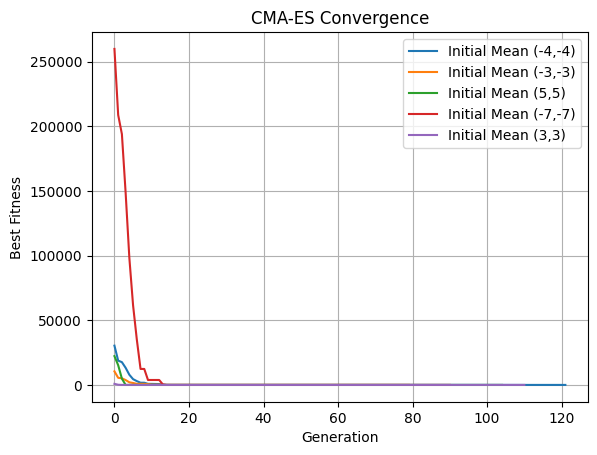

Means to reach termination:
Initial Mean (-4,-4)
Initial Mean (-3,-3)
Initial Mean (5,5)
Initial Mean (-7,-7)
Initial Mean (3,3)


In [91]:
histories = {
    "Initial Mean (-4,-4)": run_cma_es(
        rosenbrock, np.array([-4, -4]), sigma0=0.5, max_iterations=250
    ).best_fitness,
    "Initial Mean (-3,-3)": run_cma_es(
        rosenbrock, np.array([-3, -3]), sigma0=0.5, max_iterations=250
    ).best_fitness,
    "Initial Mean (5,5)": run_cma_es(
        rosenbrock, np.array([5, 5]), sigma0=0.5, max_iterations=250
    ).best_fitness,
    "Initial Mean (-7,-7)": run_cma_es(
        rosenbrock, np.array([-7, -7]), sigma0=0.5, max_iterations=250
    ).best_fitness,
    "Initial Mean (3,3)": run_cma_es(
        rosenbrock, np.array([3, 3]), sigma0=0.5, max_iterations=250
    ).best_fitness,
}
plot_convergence(histories)

print("Means to reach termination:")
for history in histories:
    if min(histories[history]) < 10e-8 or len(histories[history]) < 250:
        print(history)


(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 16:36:48 2025)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 16:36:48 2025)
Animation saved to Mean(-4,-4)cma_es_animation.gif
Animation saved to Mean(-7,-7)cma_es_animation.gif


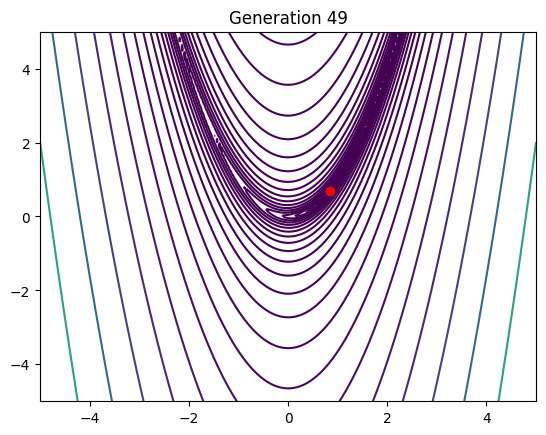

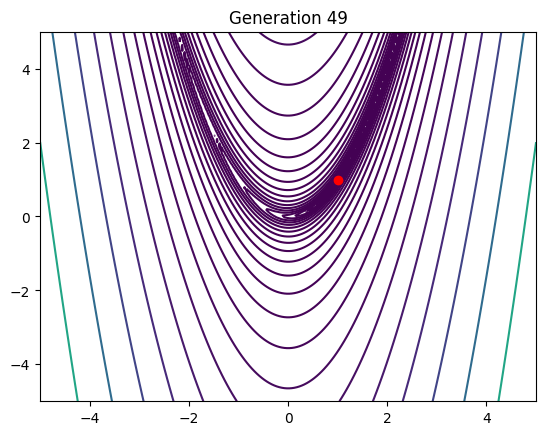

In [92]:
histories = {
    "Initial Mean (-4,-4)": run_cma_es(
        rosenbrock, np.array([-4, -4]), sigma0=0.5, max_iterations=250
    ),
    "Initial Mean (-7,-7)": run_cma_es(
        rosenbrock, np.array([-7, -7]), sigma0=0.5, max_iterations=250
    ),
}
for history in histories:
    animate_distribution(
        rosenbrock,
        histories[history].mean_history,
        histories[history].cov_history,
        name="".join(history.split()[-2:]),
    )

Generally, we can observe that the closer the mean to the center, the better initially the fitness function. <br>
However, on the plots we can also observe that the further from the center, the stepper is our fitness function loss. That can also be observed on the gifs. <br>
So, starting from away, doesn't necessarily mean the algorithm will converge last.


### Ex. 2: Effect of the Initial Global Step‐Size $\sigma_0$

1. Use [2,2] at starting point on the Rastrigin function.
2. Test $\sigma_0\in\{0.1,\,0.5,\,1,\,2,\,5\}$.
3. Record and plot

- final fitness after a fixed budget (e.g. 1000 evals)
- evolution of es.sigma over time (log scale).

4. Explain why too-small and too-large $\sigma_0$ hurt performance, relating findings to the adaptation rule.


In [ ]:
def plot_sigma(histories: dict[str, list[float]]) -> None:
    fig, ax = plt.subplots()
    for name, fitness in histories.items():
        plt.plot(fitness, label=name)
    ax.set_xscale("log")
    plt.xlabel("Generation")
    plt.ylabel("Sigma")
    plt.title("CMA-ES Sigma Evolution")
    plt.legend()
    plt.grid(True)
    plt.show()

(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 14:44:04 2025)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 14:44:04 2025)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 14:44:05 2025)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 14:44:05 2025)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 14:44:05 2025)


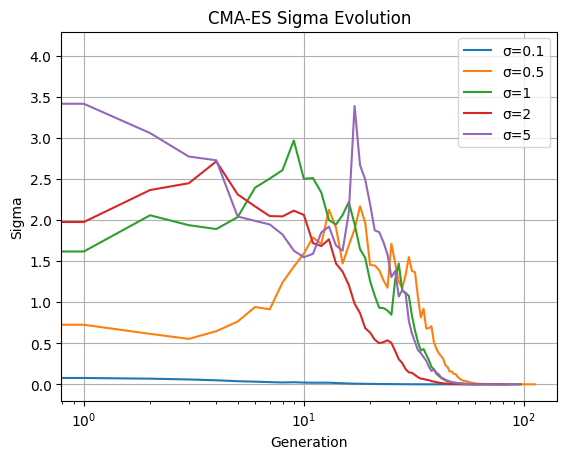

(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 14:44:05 2025)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 14:44:05 2025)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 14:44:05 2025)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 14:44:05 2025)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 14:44:05 2025)
Final fitness:
σ=0.1 : [7.959662381108174]
σ=0.5 : [1.9899181141865796]
σ=1 : [0.0]
σ=2 : [0.9949590570932898]
σ=5 : [0.9949590570932898]


In [82]:
histories = {
    "σ=0.1": run_cma_es(
        rastrigin, np.array([2, 2]), sigma0=0.1, max_iterations=1000
    ).sigma_history,
    "σ=0.5": run_cma_es(
        rastrigin, np.array([2, 2]), sigma0=0.5, max_iterations=1000
    ).sigma_history,
    "σ=1": run_cma_es(
        rastrigin, np.array([2, 2]), sigma0=1, max_iterations=1000
    ).sigma_history,
    "σ=2": run_cma_es(
        rastrigin, np.array([2, 2]), sigma0=2, max_iterations=1000
    ).sigma_history,
    "σ=5": run_cma_es(
        rastrigin, np.array([2, 2]), sigma0=5, max_iterations=1000
    ).sigma_history,
}
plot_sigma(histories)

fitness_histories = {
    "σ=0.1": run_cma_es(
        rastrigin, np.array([2, 2]), sigma0=0.1, max_iterations=1000
    ).best_fitness,
    "σ=0.5": run_cma_es(
        rastrigin, np.array([2, 2]), sigma0=0.5, max_iterations=1000
    ).best_fitness,
    "σ=1": run_cma_es(
        rastrigin, np.array([2, 2]), sigma0=1, max_iterations=1000
    ).best_fitness,
    "σ=2": run_cma_es(
        rastrigin, np.array([2, 2]), sigma0=2, max_iterations=1000
    ).best_fitness,
    "σ=5": run_cma_es(
        rastrigin, np.array([2, 2]), sigma0=5, max_iterations=1000
    ).best_fitness,
}

print("Final fitness:")
for history in fitness_histories:
    print(f"{history} : {fitness_histories[history][-1:]}")

The step size (σ) in CMA-ES controls the exploration-exploitation trade-off. Its adaptation is governed by the evolution path and covariance matrix (C) <br>
If sigma is too small:
 - The algorithm gets stuck in local optima because the search distribution shrinks too quickly.
 - Mutations become tiny, preventing exploration beyond immediate neighbors

If sigma is too large: 
 - The algorithm may fail to converge or progress very slowly
 - Unstable updates to covariance matrix become noisy

### Ex. 3: Visualising the Covariance Matrix Adaptation

1. On Sphere in 2D, log es.C every 5 generations.
2. Use the provided `animate_distribution` to produce a GIF showing the shrinking and rotation of the sampling ellipse.
3. Submit the animation and two short observations about what the animation reveals regarding step-size vs. shape adaptation.


(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 17:00:10 2025)
[[0.94610368 0.04107799]
 [0.04107799 0.83049041]]
[[0.27210921 0.08223851]
 [0.08223851 0.40643927]]
[[ 0.10979205 -0.01332304]
 [-0.01332304  0.20904972]]
[[0.0435687  0.00123719]
 [0.00123719 0.09446948]]
[[ 0.01341684 -0.00034725]
 [-0.00034725  0.037708  ]]
[[ 0.00953228 -0.00099117]
 [-0.00099117  0.01067035]]
[[0.00272563 0.0006779 ]
 [0.0006779  0.0039433 ]]
[[0.0007654  0.0001766 ]
 [0.0001766  0.00150137]]
[[ 3.34788011e-04 -3.83379225e-05]
 [-3.83379225e-05  4.74481095e-04]]
[[ 1.46110155e-04 -8.84994305e-06]
 [-8.84994305e-06  1.26178527e-04]]
[[3.29214208e-05 6.51539758e-06]
 [6.51539758e-06 6.36320672e-05]]
[[ 1.14345539e-05 -2.07396572e-07]
 [-2.07396572e-07  1.96439879e-05]]
[[4.41390834e-06 7.11899357e-07]
 [7.11899357e-07 5.24974539e-06]]
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=234, Tue May  6 17:00:10 2025)
[[0.78438385 0.20913284]
 [0.20913284 1.94480626]]
[[ 1.078

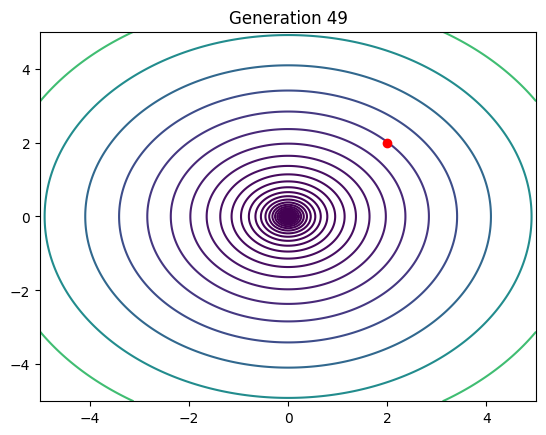

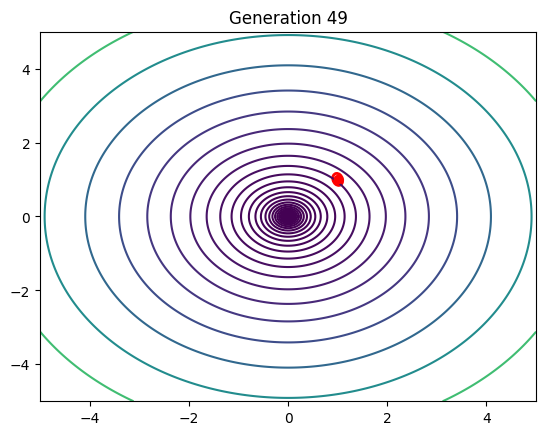

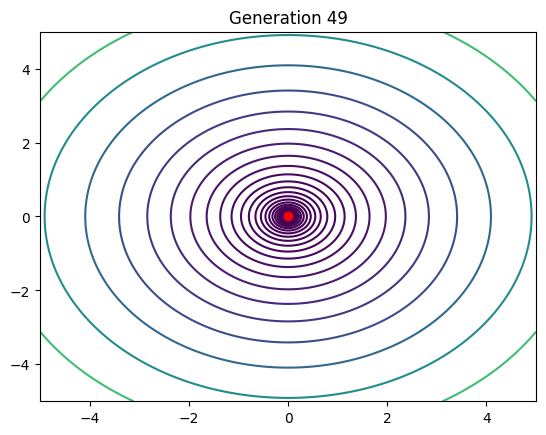

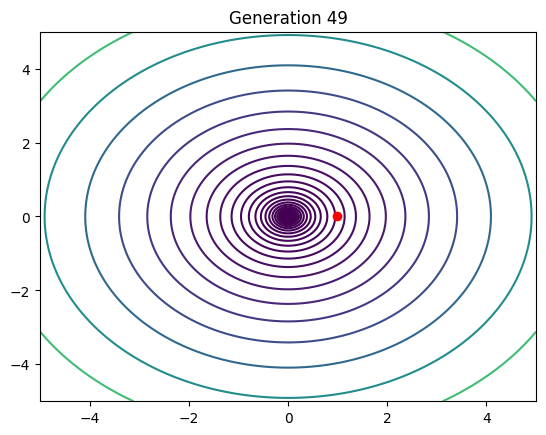

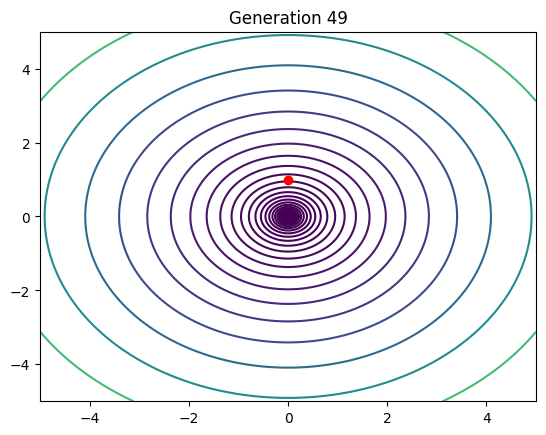

In [107]:
histories = {
    "σ=0.1": run_cma_es(rastrigin, np.array([2, 2]), sigma0=0.1, max_iterations=1000, log_C=True),
    "σ=0.5": run_cma_es(rastrigin, np.array([2, 2]), sigma0=0.5, max_iterations=1000, log_C=True),
    "σ=1": run_cma_es(rastrigin, np.array([2, 2]), sigma0=1, max_iterations=1000, log_C=True),
    "σ=2": run_cma_es(rastrigin, np.array([2, 2]), sigma0=2, max_iterations=1000, log_C=True),
    "σ=5": run_cma_es(rastrigin, np.array([2, 2]), sigma0=5, max_iterations=1000, log_C=True),
}

for history in histories:
    animate_distribution(
        sphere,
        histories[history].mean_history,
        histories[history].cov_history,
        name=history,
    )

Too-small σ restricts sampling to local regions, preventing shape adaptation from capturing global structure, while too-large σ oversamples noisy areas, corrupting shape estimation